In [ ]:
import pandas as pd
import numpy as NP
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
!pip install keras
import keras
import tensorflow as tf

In [3]:
ipl = pd.read_csv("ipl_data.csv")
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [4]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [5]:
ipl.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


In [6]:
df = ipl.drop(['runs_last_5','wickets_last_5','mid','striker','non-striker'], axis= 1)

In [7]:
consistent_teams = ['Kolkata Knight Riders','Chennai Super Kings', 'Rajastan Royals', 'Mumbai Indians', 'Kings XI Punjab','Royal Challengers Bangalore','Delhi Daredevils','Sunrisers Hyderabad']


In [8]:
df= df[(df['bat_team'].isin(consistent_teams)) & (df['bowl_team'].isin(consistent_teams))]

In [9]:
print(df['bat_team'].unique())
print(df['bowl_team'].unique())

['Kolkata Knight Riders' 'Chennai Super Kings' 'Mumbai Indians'
 'Kings XI Punjab' 'Delhi Daredevils' 'Royal Challengers Bangalore'
 'Sunrisers Hyderabad']
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Mumbai Indians'
 'Chennai Super Kings' 'Delhi Daredevils' 'Kolkata Knight Riders'
 'Sunrisers Hyderabad']


In [10]:
from datetime import datetime
df['date']=df['date'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d'))

In [11]:
df = df[df['overs']>=5.0]
df.head()

,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,total
32,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,61,0,5.1,222
33,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,Z Khan,61,1,5.2,222
34,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.3,222
35,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.4,222
36,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.5,222


In [12]:
X= df.drop({'total'},axis=1)
y= df['total']
X.head()

,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs
32,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,Z Khan,61,0,5.1
33,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,Z Khan,61,1,5.2
34,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.3
35,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.4
36,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,RT Ponting,Z Khan,61,1,5.5


In [13]:
from sklearn.preprocessing import LabelEncoder

venue_encoder = LabelEncoder()
batting_team_encoder=LabelEncoder()
bowling_team_encoder=LabelEncoder()
striker_encoder = LabelEncoder()
bowler_encoder = LabelEncoder()

X['venue'] = venue_encoder.fit_transform(X['venue'])
X['bat_team'] = batting_team_encoder.fit_transform(X['bat_team'])
X['bowl_team'] = bowling_team_encoder.fit_transform(X['bowl_team'])
X['batsman'] = striker_encoder.fit_transform(X['batsman'])
X['bowler'] = bowler_encoder.fit_transform(X['bowler'])
X.head()

,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs
32,2008-04-18,12,3,5,35,240,61,0,5.1
33,2008-04-18,12,3,5,229,240,61,1,5.2
34,2008-04-18,12,3,5,211,240,61,1,5.3
35,2008-04-18,12,3,5,211,240,61,1,5.4
36,2008-04-18,12,3,5,211,240,61,1,5.5


In [14]:
X_train = X.drop(labels = 'date', axis=1)[df['date'].dt.year<=2016]
X_test = X.drop(labels = 'date', axis=1)[df['date'].dt.year>=2017]

y_train = y[df['date'].dt.year<=2016].values
y_test = y[df['date'].dt.year>=2017].values


print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

X_train.head()

(28032, 8) (28032,)
(2778, 8) (2778,)


,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs
32,12,3,5,35,240,61,0,5.1
33,12,3,5,229,240,61,1,5.2
34,12,3,5,211,240,61,1,5.3
35,12,3,5,211,240,61,1,5.4
36,12,3,5,211,240,61,1,5.5


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(216, activation='relu'),
    keras.layers.Dense(1, activation='linear')
])
huber_loss = tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam', loss=huber_loss)

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 68.1568 - val_loss: 12.4059
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.9549 - val_loss: 11.7695
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.3958 - val_loss: 11.6418
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2846 - val_loss: 11.4985
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2054 - val_loss: 11.4031
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1713 - val_loss: 11.6472
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2203 - val_loss: 11.6010
Epoch 8/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2405 - val_loss: 12.1959
Epoch 9/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.2366 - val_loss: 11.9767
Epoch 10/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.2991 - val_loss: 11.9353
Epoch 11/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12.1249 - val_loss: 12.1569
Epoch 12/50
438/438 ━━━━━━━━━━

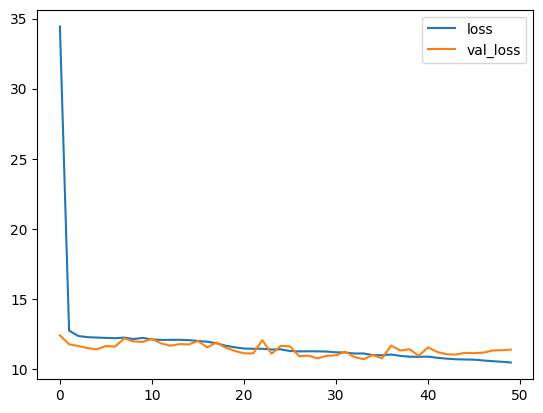

In [16]:
model.fit(X_train_scaled,y_train, epochs=50, batch_size=64, validation_data=(X_test_scaled,y_test))


# %%
model_losses = pd.DataFrame(model.history.history)
model_losses.plot()

predictions = model.predict(X_test_scaled)

# %%
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(mean_absolute_error(y_test, predictions))
print(r2_score(y_test, predictions))

In [17]:
import ipywidgets as widgets
import numpy as np
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")
venue =widgets. Dropdown (options=df['venue'].unique().tolist(),description= 'Select Venue:')
batting_team =widgets. Dropdown (options =df['bat_team'].unique().tolist(), description='Select Batting Team:')
bowling_team =widgets. Dropdown (options=df['bowl_team'].unique().tolist(), description= 'Select Batting Team:')
striker=widgets. Dropdown (options=df ['batsman'].unique().tolist(), description= 'Select Striker:')
bowler =widgets. Dropdown (options=df['bowler'].unique().tolist(), description= 'Select Bowler:')
runs =widgets. IntText(description = 'runs')
wickets =widgets. IntText(description = 'wickets')
overs =widgets. FloatText(description = 'overs')

predict_button =widgets. Button(description="Predict Score")

def predict_score(b):
    with output:
        clear_output() # Clear the previous output

    # Decode the encoded values back to their original values
        decoded_venue = venue_encoder.transform([venue.value])
        decoded_batting_team =batting_team_encoder.transform([batting_team.value])
        decoded_bowling_team= bowling_team_encoder.transform([bowling_team.value])
        decoded_striker = striker_encoder.transform([striker.value])
        decoded_bowler= bowler_encoder.transform([bowler.value])
        runs_text= int(runs.value)
        wickets_text= int(wickets.value)
        overs_text = float(overs.value)
        input = np.array([decoded_venue[0], decoded_batting_team[0], decoded_bowling_team[0], decoded_striker [0], decoded_bowler[0], runs_text, wickets_text, overs_text])
        input = input.reshape(1,-1)
        input = scaler.transform(input)
        predicted_score = model.predict(input)
        predict_score= int(predicted_score[0,0])

        print(predicted_score)

In [18]:
predict_button.on_click(predict_score)
output = widgets.Output()
display (venue, batting_team, bowling_team, striker, bowler, runs, wickets, overs, predict_button, output)

Dropdown(description='Select Venue:', options=('M Chinnaswamy Stadium', 'Punjab Cricket Association Stadium, M…

Dropdown(description='Select Batting Team:', options=('Kolkata Knight Riders', 'Chennai Super Kings', 'Mumbai …

Dropdown(description='Select Batting Team:', options=('Royal Challengers Bangalore', 'Kings XI Punjab', 'Mumba…

Dropdown(description='Select Striker:', options=('BB McCullum', 'SC Ganguly', 'RT Ponting', 'DJ Hussey', 'Moha…

Dropdown(description='Select Bowler:', options=('Z Khan', 'AA Noffke', 'JH Kallis', 'SB Joshi', 'CL White', 'P…

IntText(value=0, description='runs')

IntText(value=0, description='wickets')

FloatText(value=0.0, description='overs')

Button(description='Predict Score', style=ButtonStyle())

Output()